In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(pretrained=False)


device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Device available:  cuda


In [3]:
# 1. Access in_features directly (no [0])
num_features = model.fc.in_features

# 2. Re-assign model.fc to your new architecture
model.fc = nn.Sequential(
    nn.Linear(num_features,128),
    nn.GELU(),
    nn.Linear(128,64),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(64, 4)
)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 5

In [5]:
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR, weight_decay=5e-5)

In [6]:
#Data preparation
images=[]
labels=[]
for i in os.listdir('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'):
    for j in os.listdir(f'/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/{i}'):
        images.append(f"/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/{i}/{j}")
        labels.append(i)
    

In [7]:
data_df = pd.DataFrame(zip(images,labels), columns = ["images", "labels"])
data_df.head()

,images,labels
0,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
2,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
3,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
4,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary


In [8]:
from sklearn.model_selection import train_test_split

# X = your data, y = your labels
X_train, X_val, y_train, y_val = train_test_split(
    data_df['images'], data_df['labels'], test_size=0.2, stratify=data_df['labels'], random_state=42
)

In [9]:
train = pd.DataFrame(zip(X_train,y_train), columns = ["images", "labels"])
val = pd.DataFrame(zip(X_val,y_val), columns = ["images", "labels"])

In [10]:
images = []
labels = []

for i in os.listdir('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'):
    for j in os.listdir(f'/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/{i}'):
        images.append(f'/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/{i}/{j}')
        labels.append(i)

In [11]:
test_df = pd.DataFrame(zip(images,labels), columns = ["images", "labels"])

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
all_labels = pd.concat([train["labels"], val["labels"], test_df["labels"]])
label_encoder.fit(all_labels)



mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean,std)
    ])

In [13]:
from PIL import Image
class CustomImageDataset(Dataset):

  def __init__(self,dataframe,transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe["labels"])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx) :
    img_path = self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')

    if self.transform :
      image = self.transform(image).to(device)

    return image , label
    

In [14]:
train_dataset = CustomImageDataset(dataframe=train, transform = transform)
val_dataset = CustomImageDataset(dataframe=val, transform = transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
test_dataset = CustomImageDataset(dataframe=test_df, transform = transform)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
# 1. Freeze the whole model first
for param in model.parameters():
    param.requires_grad = False

# 2. Unfreeze only the new head (fc)
for param in model.fc.parameters():
    param.requires_grad = True


In [17]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    for images, train_labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output,train_labels)
        total_loss_train += loss.item()
        loss.backward()
        acc = (torch.argmax(output, axis = 1) == train_labels).sum().item()
        total_acc_train += acc
        optimizer.step()
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
    print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}''')
    print("==="*25)


Epoch 1/5, Train Loss: 3.3843 Train Accuracy 42.6786
Epoch 2/5, Train Loss: 3.163 Train Accuracy 48.8393
Epoch 3/5, Train Loss: 3.1106 Train Accuracy 51.8527
Epoch 4/5, Train Loss: 3.0093 Train Accuracy 55.3348
Epoch 5/5, Train Loss: 2.9007 Train Accuracy 57.1205


In [18]:
# Unfreeze everything
for param in model.parameters():
    param.requires_grad = True
# Only pass parameters that have requires_grad=True
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-4,
    weight_decay = 5e-5
)


In [19]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []
EPOCHS = 10
for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0
    for images, train_labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output,train_labels)
        total_loss_train += loss.item()
        loss.backward()
        acc = (torch.argmax(output, axis = 1) == train_labels).sum().item()
        total_acc_train += acc
        optimizer.step()

    with torch.no_grad():
        for images, val_labels in val_loader:
            out = model(images)
            loss = criterion(out,val_labels)
            total_loss_val += loss.item()
            acc = (torch.argmax(out,axis=1)== val_labels).sum().item()
            total_acc_val += acc
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
    total_acc_validation_plot.append(round(total_acc_val/(val_dataset.__len__())*100, 4))
    print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}
              Validation Loss: {round(total_loss_val/100, 4)} Validation Accuracy: {round((total_acc_val)/val_dataset.__len__() * 100, 4)}''')
    print("==="*25)


Epoch 1/10, Train Loss: 1.834 Train Accuracy 74.8214
              Validation Loss: 0.3501 Validation Accuracy: 79.7321
Epoch 2/10, Train Loss: 1.0751 Train Accuracy 85.9598
              Validation Loss: 0.2736 Validation Accuracy: 85.2679
Epoch 3/10, Train Loss: 0.6933 Train Accuracy 91.5402
              Validation Loss: 0.217 Validation Accuracy: 89.6429
Epoch 4/10, Train Loss: 0.5006 Train Accuracy 94.1295
              Validation Loss: 0.2107 Validation Accuracy: 88.9286
Epoch 5/10, Train Loss: 0.3638 Train Accuracy 95.7366
              Validation Loss: 0.1955 Validation Accuracy: 91.3393
Epoch 6/10, Train Loss: 0.2672 Train Accuracy 96.7857
              Validation Loss: 0.2151 Validation Accuracy: 89.7321
Epoch 7/10, Train Loss: 0.2309 Train Accuracy 97.1875
              Validation Loss: 0.1782 Validation Accuracy: 92.2321
Epoch 8/10, Train Loss: 0.1461 Train Accuracy 98.2366
              Validation Loss: 0.2035 Validation Accuracy: 90.5357
Epoch 9/10, Train Loss: 0.1488 Tra

In [20]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs , test_labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions , axis = 1)==test_labels).sum().item()
    loss_total = criterion(predictions,test_labels)
    total_loss_test += loss_total.item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 87.4375 and Loss is 0.0642


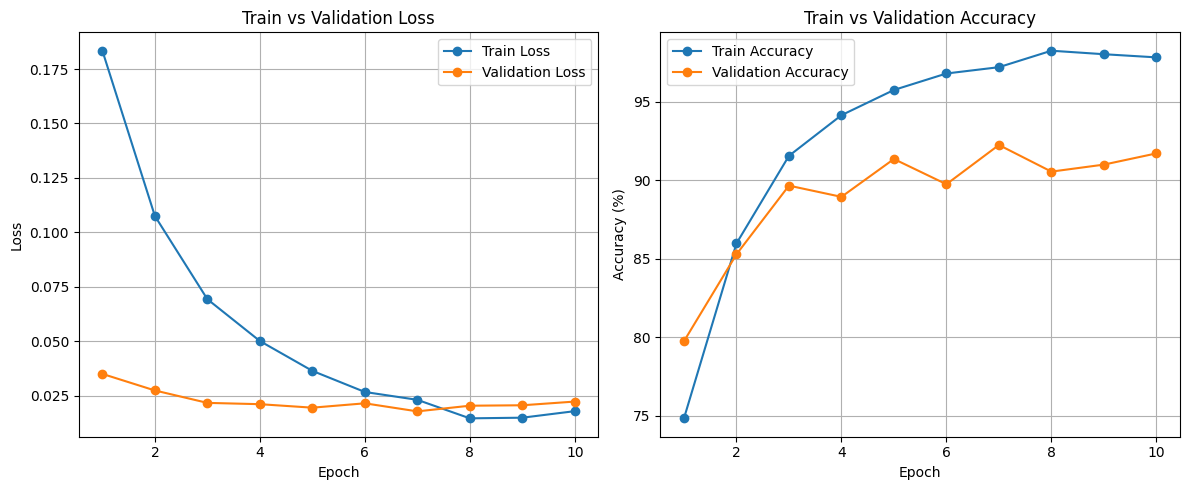

In [26]:
import matplotlib.pyplot as plt
# Plot Loss
EPOCHS=[1,2,3,4,5,6,7,8,9,10]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(EPOCHS, total_loss_train_plot, 'o-', label='Train Loss')
plt.plot(EPOCHS, total_loss_validation_plot, 'o-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(EPOCHS, total_acc_train_plot, 'o-', label='Train Accuracy')
plt.plot(EPOCHS, total_acc_validation_plot , 'o-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()